In [1]:
using LinearAlgebra, QuantumOptics, DifferentialEquations, Plots, SparseArrays, JLD2, FileIO

## 2 atoms Encoding

### Initialization

In [21]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

In [22]:
α = -sqrt(0.82)
β = sqrt(1 - α^2)
ψ_1 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_2 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [23]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_1r_atom1 = σx_1r ⊗ I2

    σx_1r_atom2 = I2 ⊗ σx_1r
    σx_0r_atom2 = I2 ⊗ σx_0r
    n_r_atom2 = I2 ⊗ n_r
    nn_r12 = n_r ⊗ n_r

    return (σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, n_r_atom2, nn_r12)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, n_r_atom2, nn_r12 = ops

    H = (Ω1/2 .* σx_1r_atom1 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* nn_r12) #+
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


ErrorException: invalid redefinition of constant Main.ops

In [24]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [ ]:
tspan = [0.0:0.1:(2π+sqrt(2)π);];
# tspan = [0.0:0.1:100;]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [ ]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []


k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2)
n0_atom2 = (I2 ⊗ n0)
n1_atom1 = (n1 ⊗ I2)
n1_atom2 = (I2 ⊗ n1)
nr_atom1 = (nr ⊗ I2)
nr_atom2 = (I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
end

In [ ]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

In [ ]:
plot(tspan,pop0_atom2, label="Atom 1 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 1 in state 1")
plot!(tspan,popr_atom2, label="Atom 1 in state r")


In [ ]:
fidelities = []
ψ_target = α .* reduce(kron,[b,b]) + β .* reduce(kron,[a,a])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data)))^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

## 3 atoms Encoding

### Initialization

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = sqrt(0.5)
β = sqrt(1 - α^2)
ψ_2 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_1 = a
ψ_3 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2) ⊗ Ket(NLevelBasis(3), ψ_3)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_0r_atom1 = σx_0r ⊗ I2 ⊗ I2
    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2
    n_r_atom1 = n_r ⊗ I2 ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2


    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2

    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r
    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r
    nn_r23 = I2 ⊗ n_r ⊗ n_r

    return (σx_0r_atom1, σx_1r_atom1, σx_1r_atom2, σx_0r_atom3, σx_1r_atom3, n_r_atom1, n_r_atom3, nn_r12, nn_r23)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
        Ω3 = 1.0
    elseif t <= π + sqrt(2)π
        Ω1 = 0.0
        Ω2 = 1.0
        Ω3 = 1.0
    else
        Ω1 = 1.0
        Ω2 = 0.0
        Ω3 = 0.0
    end
    # if t<τ
    # Ω1 = 0.0
    # Ω2 = Ω0 * sin(alpha) * exp(-(t-τ-70)^2/T^2)
    # Ω3 = Ω0 * cos(alpha) * exp(-(t-τ-70)^2/T^2) + Ω0 * exp(-(t+τ-70)^2/T^2)
    
    # else
    #     Ω1 = 0.0
    #     Ω2 = 0.0
    #     Ω3 = 0.0
    # end

    σx_0r_atom1, σx_1r_atom1, σx_1r_atom2, σx_0r_atom3, σx_1r_atom3, n_r_atom1, n_r_atom3, nn_r12, nn_r23 = ops

    H = (Ω1/2 .* σx_1r_atom2 + Ω2/2 .* (σx_0r_atom1) + Ω3/2 .* (σx_1r_atom1) + Δ_0 .* n_r_atom1 + V_nn .* nn_r12 
         + Ω2/2 .* (σx_0r_atom3) + Ω3/2 .* (σx_1r_atom3) + Δ_0 .* n_r_atom3 + V_nn .* nn_r23)

    # H_fstirap = (Ω2/2 .* (σx_0r_atom1) + Ω3/2 .* (σx_1r_atom1))# + Ω2/2 .* (σx_0r_atom3) + Ω3/2 .* (σx_1r_atom3))
    # return H_fstirap
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [4]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;
const alpha = π/4
const τ = 0.7*20.0
const T = 20.0

20.0

In [5]:
# tspan = [0:0.1:150;];
tspan = [0.0:0.1:(π+sqrt(2)π+3π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [6]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))
end

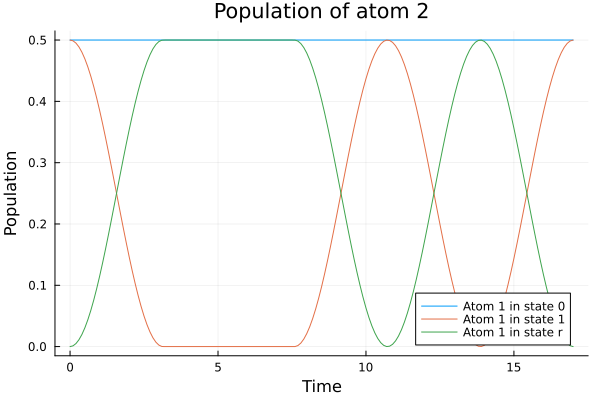

In [7]:
plot(tspan,pop0_atom2, label="Atom 1 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 1 in state 1")
plot!(tspan,popr_atom2, label="Atom 1 in state r")

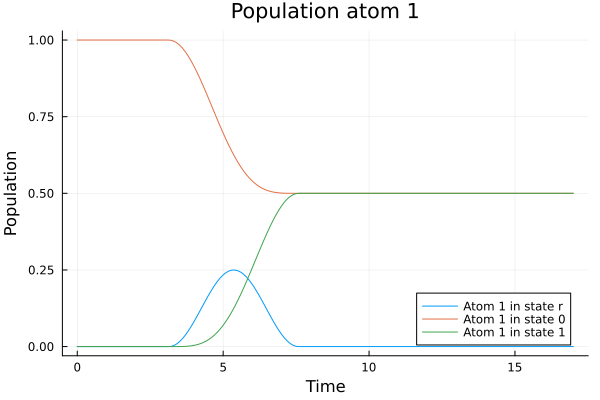

In [8]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

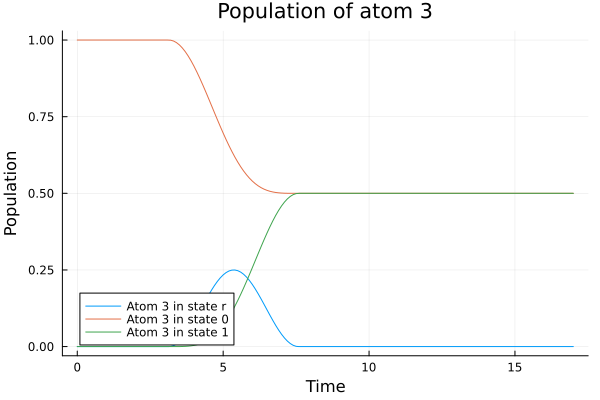

In [9]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population of atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

In [10]:
fidelities = []
ψ_target = α .* reduce(kron,[b,b,b]) + β .* reduce(kron,[a,a,a])
# ψ_one = a
# ψ_target = reduce(kron,[ψ_target1,ψ_one])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data)))^2)
end


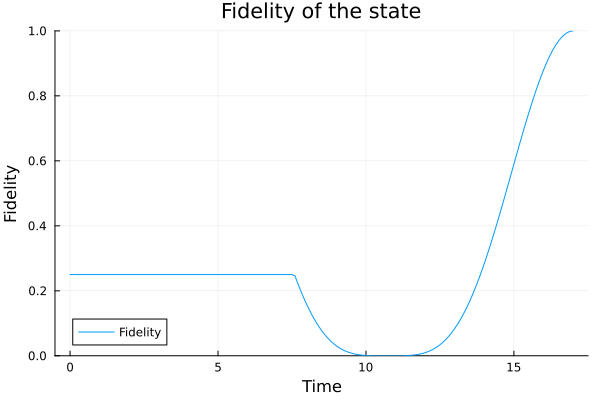

In [11]:
plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

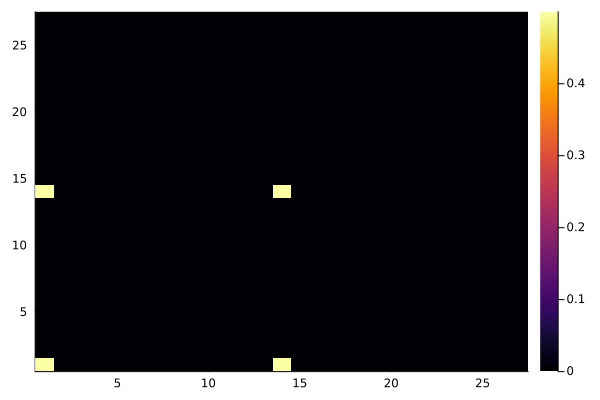

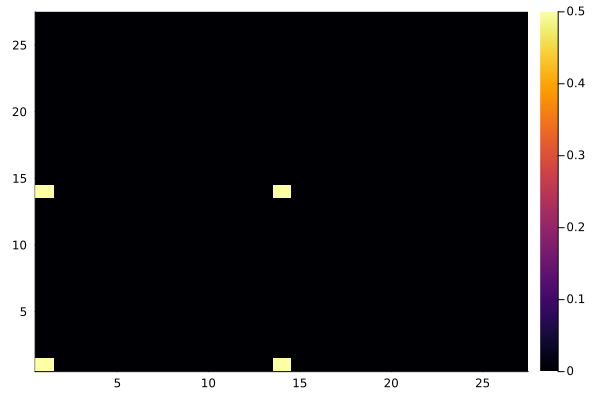

In [12]:
display(heatmap(real.(sol[end].data)))
display(heatmap(real.(ρ_target)))

## 3 atoms Ancilla Encoding

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = 1
β = sqrt(1 - α^2)
# ψ_2 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = 
# ψ_2 = a
# ψ_3 = a

ψ_a = α .* reduce(kron,[b,b,b]) + β .* reduce(kron,[a,a,a])

full_basis = CompositeBasis([NLevelBasis(3) for _ in 1:3]...)
ψ_a_op = Ket(full_basis,ψ_a)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2

    σx_0r_atom2 = I2 ⊗ σx_0r ⊗ I2
    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2
    n_r_atom2 = I2 ⊗ n_r ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2
    nn_r23 = I2 ⊗ n_r ⊗ n_r

    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r

    return (σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, σx_1r_atom3, n_r_atom2, nn_r12, nn_r23)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, σx_1r_atom3, n_r_atom2, nn_r12, nn_r23 = ops

    H = (Ω1/2 .* σx_1r_atom1 + Ω1/2 .* σx_1r_atom3 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* (nn_r12 + nn_r23))
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [4]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [5]:
# tspan = [0.0:0.1:(3.5π);];
tspan = [0.0:0.1:(2π+sqrt(2)π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [6]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))
end

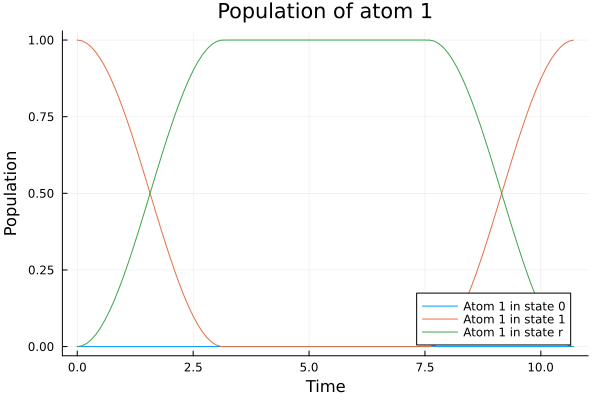

In [7]:
plot(tspan,pop0_atom1, label="Atom 1 in state 0", title="Population of atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom1, label="Atom 1 in state 1")
plot!(tspan,popr_atom1, label="Atom 1 in state r")


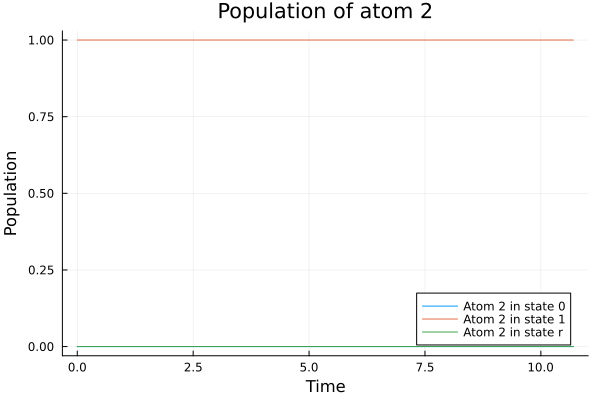

In [8]:
plot(tspan,pop0_atom2, label="Atom 2 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 2 in state 1")
plot!(tspan,popr_atom2, label="Atom 2 in state r")


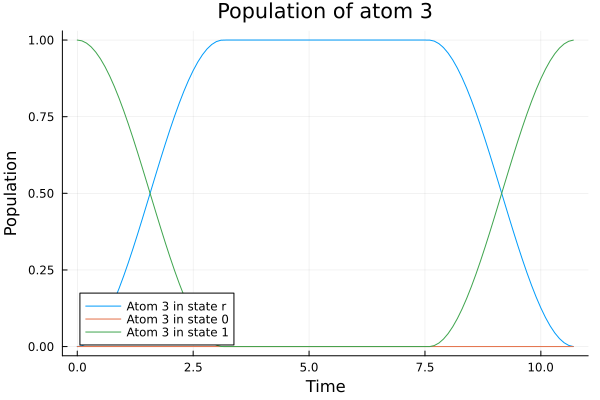

In [9]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population of atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

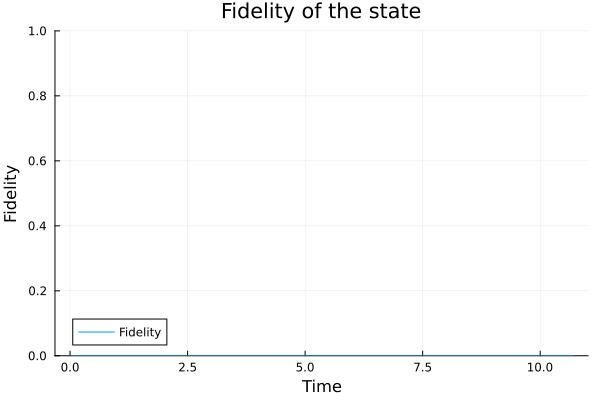

In [11]:
fidelities = []

ψ_target = Ket(NLevelBasis(3),b) ⊗ Ket(NLevelBasis(3),a) ⊗ Ket(NLevelBasis(3),a) 
ρ_target = ψ_target ⊗ dagger(ψ_target)

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target.data*sqrt(ρ.data)))^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

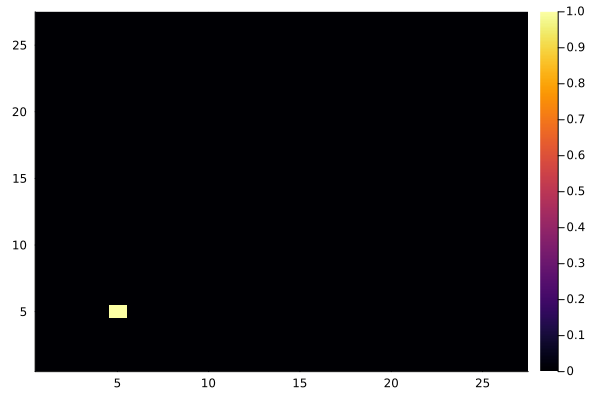

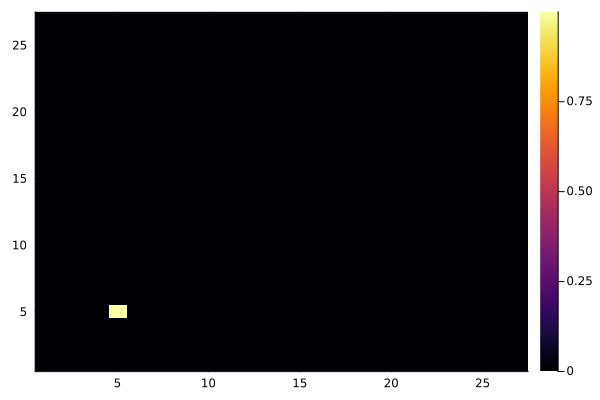

In [11]:
display(heatmap(real.(ρ_target.data)))
display(heatmap(real.(sol[end].data)))

## 3 atoms Correction Protocol

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

# α = 1
# β = sqrt(1 - α^2)
# ψ_2 = α .* b + β .* a; #Qubit state |ψ_1>
ψ_1 = a
ψ_2 = b
ψ_3 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2) ⊗ Ket(NLevelBasis(3), ψ_3)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_0r_atom1 = σx_0r ⊗ I2 ⊗ I2
    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2
    n_r_atom1 = n_r ⊗ I2 ⊗ I2 

    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2
    nn_r23 = I2 ⊗ n_r ⊗ n_r

    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r
    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r

    return (σx_1r_atom2, σx_0r_atom1, σx_1r_atom1, σx_0r_atom3, σx_1r_atom3, n_r_atom3, n_r_atom1, nn_r12, nn_r23)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom2, σx_0r_atom1, σx_1r_atom1, σx_0r_atom3, σx_1r_atom3, n_r_atom3, n_r_atom1, nn_r12, nn_r23 = ops

    H = (Ω1/2 .* σx_1r_atom2 
        + Ω2/2 .*  (σx_0r_atom3 + σx_1r_atom3) + Δ_0 .* n_r_atom3 + V_nn .* nn_r23)
    
    # (Ω1/2 .* σx_1r_atom1 + Ω1/2 .* σx_1r_atom3 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* (nn_r12 + nn_r23))
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [4]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [5]:
# tspan = [0.0:0.1:(3.5π);];
tspan = [0.0:0.1:(2π+sqrt(2)π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [6]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))
end

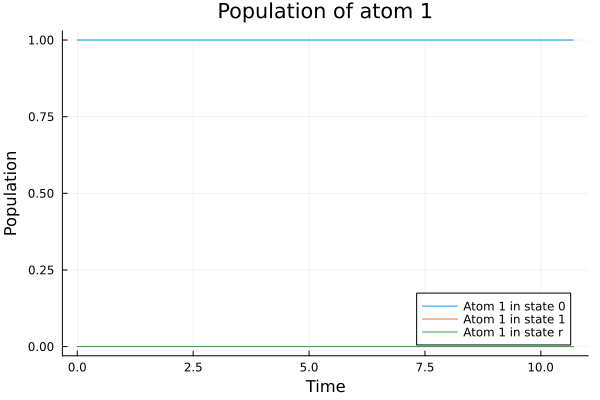

In [7]:
plot(tspan,pop0_atom1, label="Atom 1 in state 0", title="Population of atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom1, label="Atom 1 in state 1")
plot!(tspan,popr_atom1, label="Atom 1 in state r")


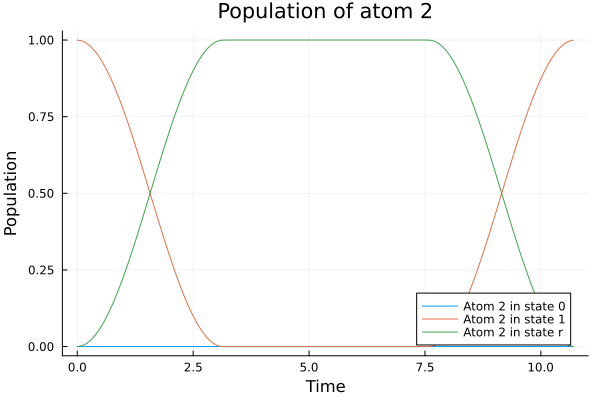

In [8]:
plot(tspan,pop0_atom2, label="Atom 2 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 2 in state 1")
plot!(tspan,popr_atom2, label="Atom 2 in state r")

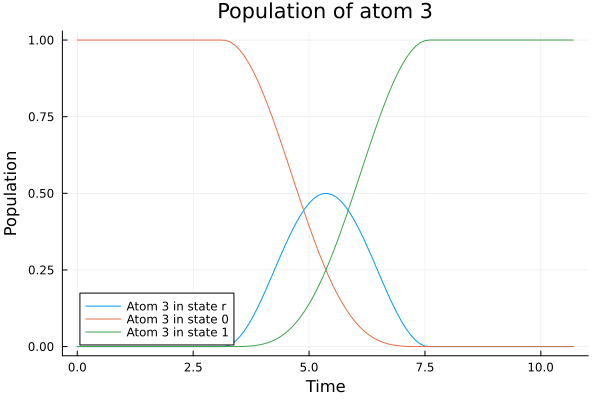

In [9]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population of atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

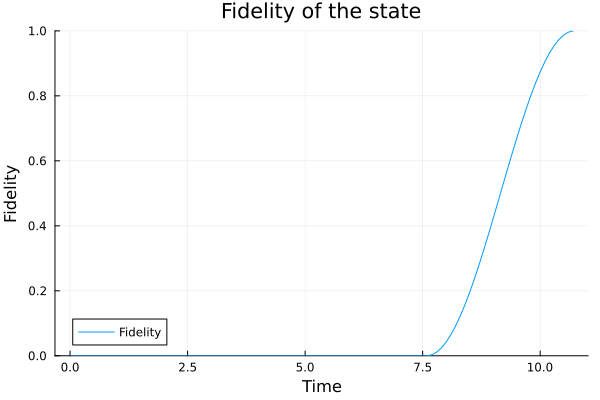

In [10]:
fidelities = []

ψ_target = Ket(NLevelBasis(3),a) ⊗ Ket(NLevelBasis(3),b) ⊗ Ket(NLevelBasis(3),b) 
ρ_target = ψ_target ⊗ dagger(ψ_target)

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target.data*sqrt(ρ.data)))^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

## Hadamard Gate - fSTIRAP

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

ψ_1 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_0r_atom1 = σx_0r 
    σx_1r_atom1 = σx_1r 

    return (σx_0r_atom1, σx_1r_atom1)
end

const ops = Precomputed_ops();


function Ht(t)

    Ω2 = Ω0 * sin(alpha) * exp(-(t-τ-70)^2/T^2)
    Ω3 = Ω0 * cos(alpha) * exp(-(t-τ-70)^2/T^2) + Ω0 * exp(-(t+τ-70)^2/T^2)
    
    σx_0r_atom1, σx_1r_atom1 = ops

    H_fstirap = (Ω2/2 .* (σx_0r_atom1) + Ω3/2 .* (σx_1r_atom1))
    return H_fstirap
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [4]:
# const Δ_0 = -1000
# const Ω1 = 1.0
const Ω0 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
# const V_nn = 1000;
const alpha = π/4
const τ = 0.7*20.0
const T = 20.0

20.0

In [5]:
tspan = [0:0.1:150;];
# tspan = [0.0:0.1:(π+sqrt(2)π+3π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

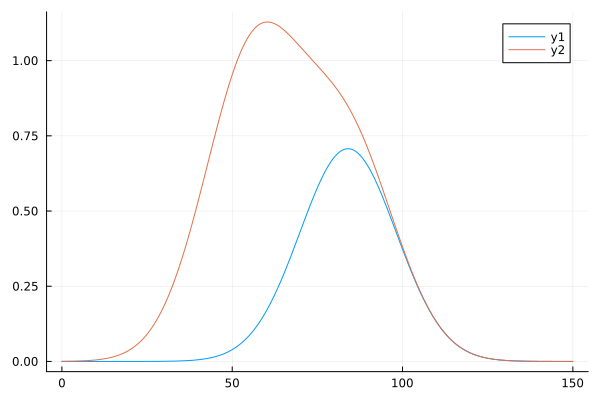

In [6]:
Ω_pump = []
Ω_stokes = []

# tspan = [0:0.1:150;];

for t in tspan
    Ω2 = Ω0 * sin(alpha) * exp(-(t-τ-70)^2/T^2)
    Ω3 = Ω0 * exp(-(t+τ-70)^2/T^2) + Ω0 * cos(alpha) * exp(-(t-τ-70)^2/T^2)
    push!(Ω_pump,Ω2)
    push!(Ω_stokes,Ω3)
end

plot(tspan,Ω_pump)
plot!(tspan,Ω_stokes)

In [7]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)



for ρ in sol
    push!(popr_atom1, real(tr(nr*ρ)))
    push!(pop0_atom1, real(tr(n0*ρ)))
    push!(pop1_atom1, real(tr(n1*ρ)))
end

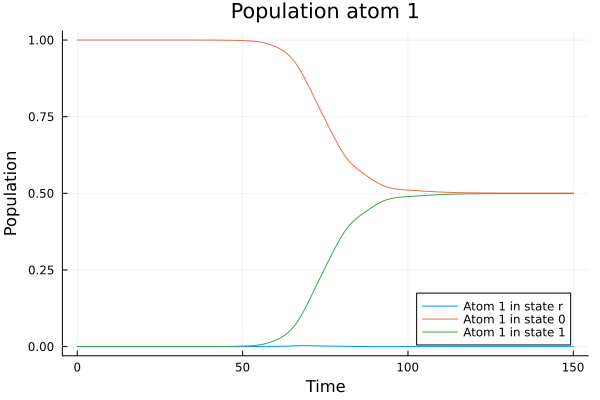

In [8]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

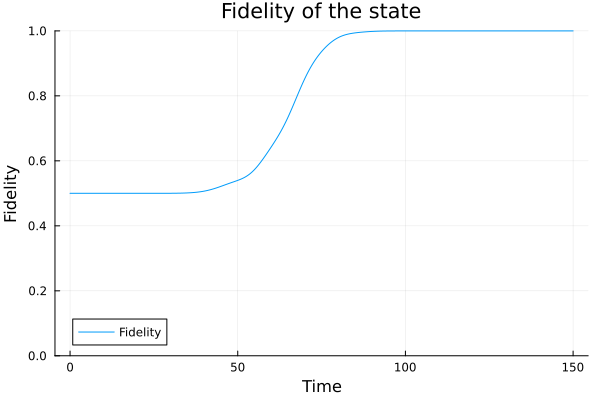

In [9]:
fidelities = []
ϕ1 = sqrt(0.5) .* b - sqrt(0.5) .* a

ρ_target = ϕ1 * ϕ1'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data)))^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

In [10]:
fidelities[end]

0.9999646614046171 + 1.134357491395286e-11im

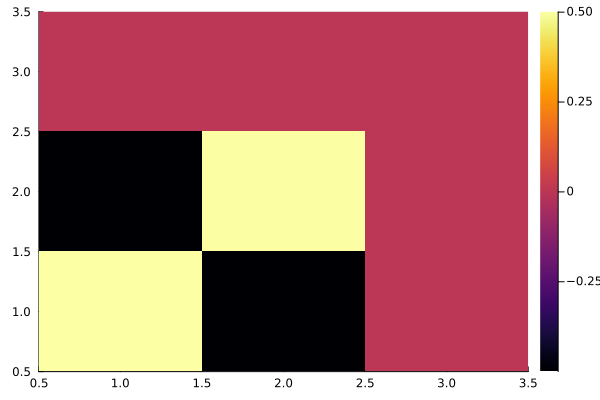

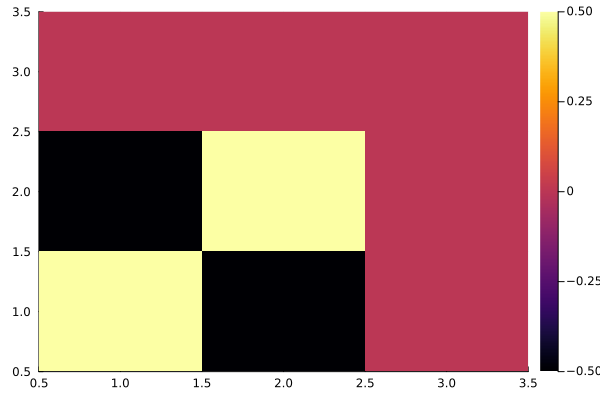

In [11]:
display(heatmap(real.(sol[end].data)))
display(heatmap(real.(ρ_target)))

## Hadamard - Raman Pi/2 Pulse

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = 1
β = sqrt(1 - α^2)
ψ_initial = α .* b + β .* a; #Qubit state |ψ_1>

In [3]:
function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_0r_atom1 = σx_0r #⊗ I2 ⊗ I2 
    σx_1r_atom1 = σx_1r #⊗ I2 ⊗ I2
    n_r_atom1 = n_r #⊗ I2 ⊗ I2

    σx_0r_atom2 = I2 ⊗ σx_0r ⊗ I2
    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2
    n_r_atom2 = I2 ⊗ n_r ⊗ I2

    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r
    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r

    return (σx_0r_atom1, σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, σx_0r_atom3, σx_1r_atom3, n_r_atom1, n_r_atom2, n_r_atom3)
end

const ops = Precomputed_ops();


function Ht(t)

    Ω1 = 1.0
    Ω2 = 1.0
    Δ_0 = 100.0

    σx_0r_atom1, σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, σx_0r_atom3, σx_1r_atom3, n_r_atom1, n_r_atom2, n_r_atom3 = ops

    H = (Ω1 .* σx_0r_atom1 + Ω2 .* σx_1r_atom1 + Δ_0 .* (n_r_atom1))
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (real.(H), real.(J), real.(dagger.(J)))
end


f (generic function with 1 method)

In [4]:
# const Δ_0 = 5
# const γ_Decay = 0.0
# const γ_dephase = 0.0
# const V_nn = 1000;

virtual_z = [exp(-1im * π/4) 0 0; 
             0 exp(1im * π/4) 0; 
             0 0 1]

ψ0_ket = virtual_z * ψ_initial
ψ0_ket = Ket(NLevelBasis(3), ψ0_ket)
ρ0 = ψ0_ket ⊗ dagger(ψ0_ket);
             

Operator(dim=3x3)
  basis: NLevel(N=3)
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

In [5]:
tspan = [0.0:0.01:(25π);]
# tout, sol = timeevolution.master_dynamic(tspan, ρ0, f; alg=AutoTsit5(ABDF2(autodiff=false)));
tout, sol = timeevolution.mcwf_dynamic(tspan, ψ0_ket, f);

In [6]:
sol[end]

Ket(dim=3)
  basis: NLevel(N=3)
 -0.7067583582738062 + 0.00012888871747797im
 0.00034873263109551 + 0.7072359796223884im
 0.01682943737733795 - 0.00515014062795386im

In [7]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = n0 #⊗ I2 ⊗ I2)
# n0_atom2 = I2 #⊗ n0 ⊗ I2)
# n0_atom3 = I2 #⊗ I2 ⊗ n0)

n1_atom1 = n1 #⊗ I2 ⊗ I2)
# n1_atom2 = (I2 ⊗ n1 ⊗ I2)
# n1_atom3 = (I2 ⊗ I2 ⊗ n1)

nr_atom1 = nr #⊗ I2 ⊗ I2)
# nr_atom2 = (I2 ⊗ nr ⊗ I2)
# nr_atom3 = (I2 ⊗ I2 ⊗ nr)


for ρ in sol

    push!(popr_atom1, real(expect(nr_atom1,ρ)))
    push!(pop1_atom1, real(expect(n1_atom1,ρ)))
    push!(pop0_atom1, real(expect(n0_atom1,ρ)))
end

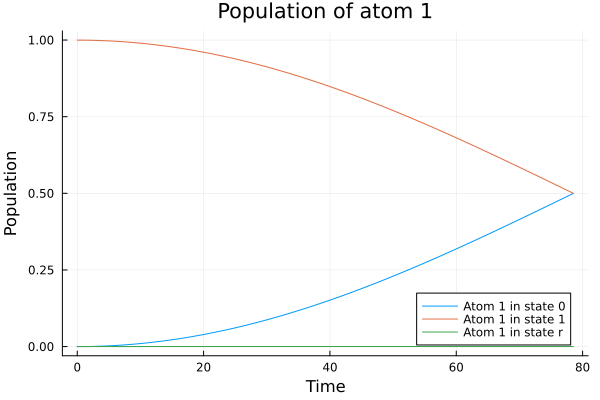

In [8]:
plot(tspan,pop0_atom1, label="Atom 1 in state 0", title="Population of atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom1, label="Atom 1 in state 1")
plot!(tspan,popr_atom1, label="Atom 1 in state r")

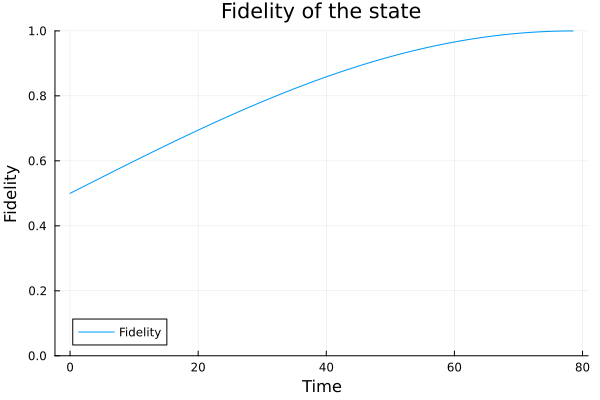

In [9]:
fidelities = []

ψ_sp = sqrt(1/2) .* a + sqrt(1/2) .* b
# ψ_sp = b

ψ_target = Ket(NLevelBasis(3), ψ_sp)
ρ_target = ψ_target ⊗ dagger(ψ_target)

for ψ in sol
    ψ_new = virtual_z * ψ.data
    push!(fidelities,abs(dagger(ψ_target) * Ket(NLevelBasis(3),ψ_new))^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

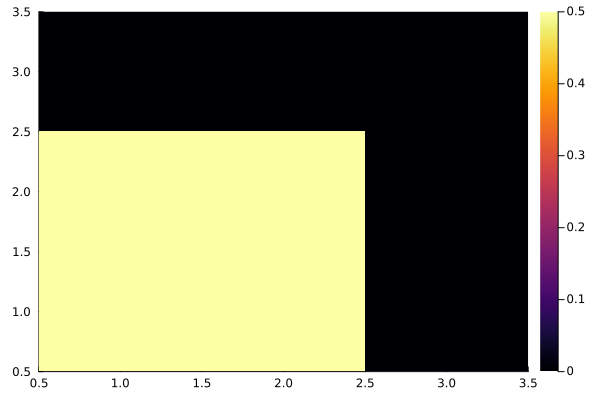

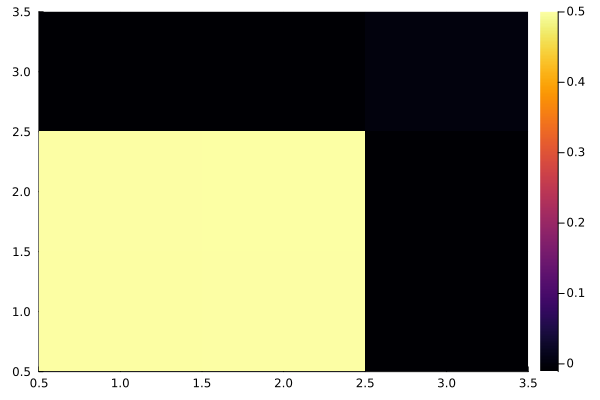

In [10]:
ρ_obtained = Ket(NLevelBasis(3), virtual_z * sol[end].data) ⊗ dagger(Ket(NLevelBasis(3), virtual_z * sol[end].data))

display(heatmap(real.(ρ_target.data)))
display(heatmap(real.(ρ_obtained.data)))

In [11]:
sol[end]

Ket(dim=3)
  basis: NLevel(N=3)
 -0.7067583582738062 + 0.00012888871747797im
 0.00034873263109551 + 0.7072359796223884im
 0.01682943737733795 - 0.00515014062795386im

In [12]:
ψ = Ket(NLevelBasis(3), virtual_z * sol[end].data)

Ket(dim=3)
  basis: NLevel(N=3)
 -0.4996624897095327 + 0.49984476588182686im
  -0.499844765881833 + 0.5003379482983704im
 0.01682943737733795 - 0.00515014062795386im

In [24]:
fidelity = abs(dagger(ψ_target) * ψ)^2

0.9996901078623252

|0> ------> (i|0> - |1>)/√2 --------> (1 - i) * (|0> - |1>)/2 

|1> ------> (i|0> + 1|1>)/√2 --------> (-1 + i) (|0> + |1>)/2 

## Hadamard on Multi Atoms

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = 0
β = sqrt(1 - α^2)
ψ1 = α .* b + β .* a; #Qubit state |ψ_1>
ψ2 = α .* b + β .* a; #Qubit state |ψ_2>
# ψ3 = α .* b + β .* a; #Qubit state |ψ_3>

ψ_initial = Ket(NLevelBasis(3), ψ1) ⊗ Ket(NLevelBasis(3), ψ2 )# ⊗ Ket(NLevelBasis(3), ψ3);

Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [3]:
function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_0r_atom1 = σx_0r ⊗ I2 #⊗ I2 
    σx_1r_atom1 = σx_1r ⊗ I2 #⊗ I2
    n_r_atom1 = n_r ⊗ I2 #⊗ I2

    σx_0r_atom2 = I2 ⊗ σx_0r #⊗ I2
    σx_1r_atom2 = I2 ⊗ σx_1r #⊗ I2
    n_r_atom2 = I2 ⊗ n_r #⊗ I2

    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r
    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r

    return (σx_0r_atom1, σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, n_r_atom1, n_r_atom2, n_r_atom3, σx_0r_atom3, σx_1r_atom3)
end

const ops = Precomputed_ops();


function Ht(t)

    Ω1 = 1.0
    Ω2 = 1.0
    Δ_0 = 100.0

    σx_0r_atom1, σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, n_r_atom1, n_r_atom2, n_r_atom3, σx_0r_atom3, σx_1r_atom3 = ops

    H = (Ω1 .* σx_0r_atom1 + Ω2 .* σx_1r_atom1 + Ω1 .* σx_0r_atom2 + Ω2 .* σx_1r_atom2 #+ Ω1 .* σx_0r_atom3 + Ω2 .* σx_1r_atom3
        + Δ_0 .* (n_r_atom1) + Δ_0 .* (n_r_atom2)) #+ Δ_0 .* (n_r_atom3))
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (real.(H), real.(J), real.(dagger.(J)))
end


f (generic function with 1 method)

In [4]:
# const Δ_0 = 5
# const γ_Decay = 0.0
# const γ_dephase = 0.0
# const V_nn = 1000;

# virtual_z = [exp(-1im * -π/4) 0 0; 
#              0 exp(1im * -π/4) 0; 
#              0 0 1]
basi = NLevelBasis(3)
virtual_z_single_gate = exp(-1im * π/4) * transition(basi, 1, 1) + exp(1im * π/4) * transition(basi, 2, 2) + transition(basi, 3, 3)
virtual_z = virtual_z_single_gate ⊗ virtual_z_single_gate #⊗ virtual_z_single_gate

ψ0_ket = virtual_z * ψ_initial
ψ0_ket /= norm(ψ0_ket)  # Normalize the state
# ψ0_ket = Ket(NLevelBasis(3), ψ0_ket)
ρ0 = ψ0_ket ⊗ dagger(ψ0_ket);
             

Operator(dim=9x9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 1.0+0.0im  0.0-0.0im  0.0-0.0im  …  0.0-0.0im  0.0-0.0im  0.0-0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

In [18]:
virtual_z_single_gate

Operator(dim=3x3)
  basis: NLevel(N=3)
 0.7071067811865476 - 0.7071067811865475im  …       ⋅     
                     ⋅                              ⋅     
                     ⋅                         1.0 + 0.0im

In [5]:
tspan = [0.0: 0.1:(25*π);]
# tout, sol = timeevolution.master_dynamic(tspan, ρ0, f; alg=AutoTsit5(ABDF2(autodiff=false)));
tout, sol = timeevolution.mcwf_dynamic(tspan, ψ0_ket, f);

In [6]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = n0 ⊗ I2 #⊗ I2
n0_atom2 = I2 ⊗ n0 #⊗ I2
n0_atom3 = I2 ⊗ I2 #⊗ n0

n1_atom1 = n1 ⊗ I2 #⊗ I2
n1_atom2 = I2 ⊗ n1 #⊗ I2
n1_atom3 = I2 ⊗ I2 #⊗ n1 

nr_atom1 = nr ⊗ I2 #⊗ I2
nr_atom2 = I2 ⊗ nr #⊗ I2
nr_atom3 = I2 ⊗ I2 #⊗ nr


for ρ in sol

    push!(popr_atom1, real(expect(nr_atom1,ρ)))
    push!(pop1_atom1, real(expect(n1_atom1,ρ)))
    push!(pop0_atom1, real(expect(n0_atom1,ρ)))

    push!(popr_atom2, real(expect(nr_atom2,ρ)))
    push!(pop0_atom2, real(expect(n0_atom2,ρ)))
    push!(pop1_atom2, real(expect(n1_atom2,ρ)))

    # push!(pop0_atom3, real(expect(n0_atom3,ρ)))
    # push!(pop1_atom3, real(expect(n1_atom3,ρ)))
    # push!(popr_atom3, real(expect(nr_atom3,ρ)))
end

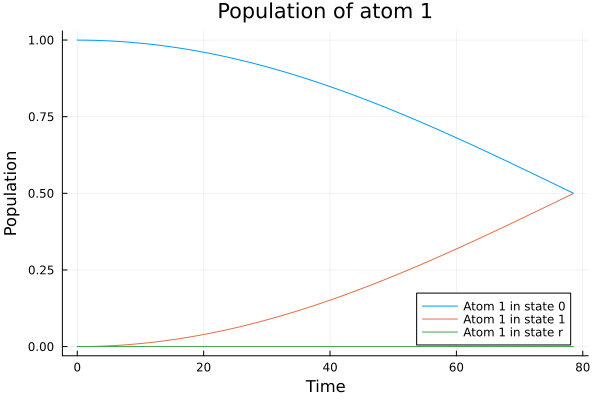

In [7]:
plot(tspan,pop0_atom1, label="Atom 1 in state 0", title="Population of atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom1, label="Atom 1 in state 1")
plot!(tspan,popr_atom1, label="Atom 1 in state r")

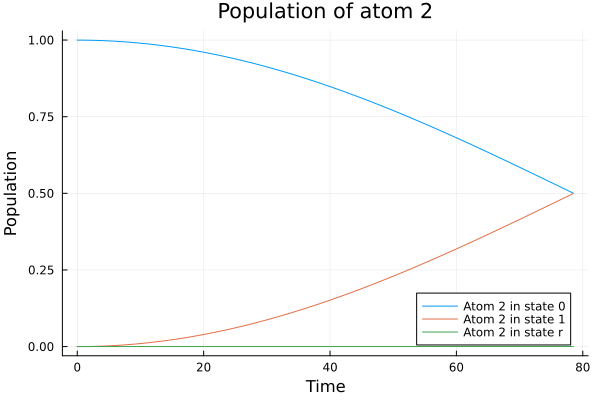

In [8]:
plot(tspan,pop0_atom2, label="Atom 2 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 2 in state 1")
plot!(tspan,popr_atom2, label="Atom 2 in state r")

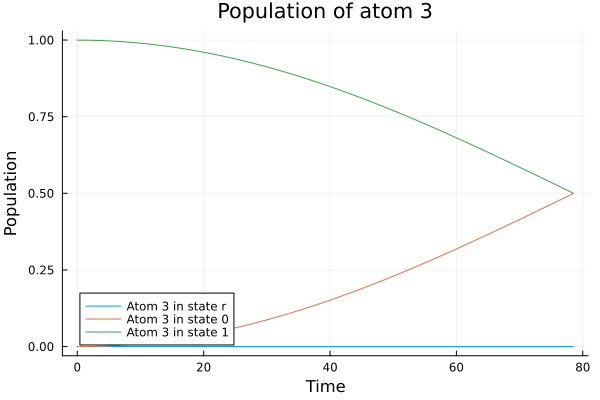

In [21]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population of atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

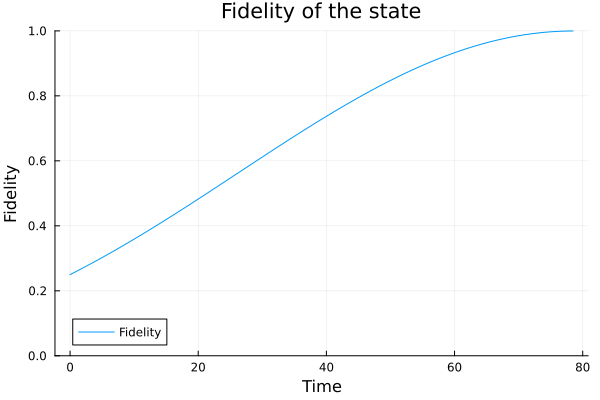

In [10]:
fidelities = []

plus = sqrt(1/2) .* a + sqrt(1/2) .* b
minus = sqrt(1/2) .* a - sqrt(1/2) .* b

plus = Ket(NLevelBasis(3), plus)
minus = Ket(NLevelBasis(3), minus)

ψ_target = minus ⊗ minus #⊗ plus
# ψ_target = Ket(NLevelBasis(3), b) ⊗ Ket(NLevelBasis(3), b) ⊗ Ket(NLevelBasis(3), b)
ρ_target = ψ_target ⊗ dagger(ψ_target)

for ψ in sol
    ψ /= norm(ψ)  # Normalize the state
    ψ_new = virtual_z * ψ
    ψ_new /= norm(ψ_new)  # Normalize the state
    push!(fidelities,abs(dagger(ψ_target) * ψ_new)^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

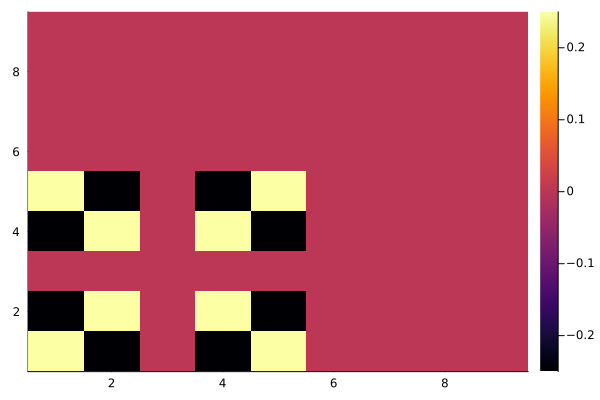

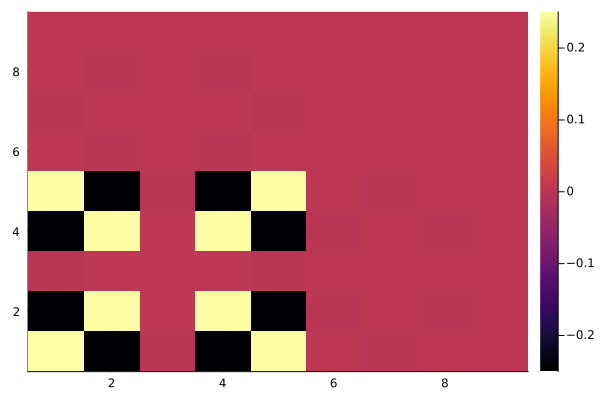

In [11]:
ρ_obtained = (virtual_z * sol[end]) ⊗ dagger(virtual_z * sol[end])

display(heatmap(real.(ρ_target.data)))
display(heatmap(real.(ρ_obtained.data)))

In [12]:
ψ_end = sol[end] / norm(sol[end])
# virtual_z * ψ_end

Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
   0.5004476444172592 - 0.0005149476131279im
  0.00048094818173902 + 0.49996646861868055im
 -0.00537998269996094 + 0.00203879658890636im
  0.00048094818173902 + 0.49996646861868055im
 -0.49948574805377655 + 0.00044701138703838im
 -0.00203607826034514 - 0.00537483550236347im
 -0.00537998269996094 + 0.00203879658890636im
 -0.00203607826034514 - 0.00537483550236347im
    6.695091315378e-5 - 1.881133635949e-5im

In [14]:
virtual_z * ψ_end

Ket(dim=9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 -0.00051494761312779 - 0.5004476444172592im
  0.00048094818173902 + 0.49996646861868055im
   -0.002362575356333 + 0.00524586914328438im
  0.00048094818173902 + 0.49996646861868055im
 -0.00044701138703849 - 0.49948574805377655im
  0.00236085788656685 - 0.00524030737639997im
   -0.002362575356333 + 0.00524586914328438im
  0.00236085788656685 - 0.00524030737639997im
    6.695091315378e-5 - 1.881133635949e-5im

In [13]:
ψ_target.data

9-element Vector{ComplexF64}:
  0.5000000000000001 + 0.0im
 -0.5000000000000001 + 0.0im
                 0.0 + 0.0im
 -0.5000000000000001 + 0.0im
  0.5000000000000001 - 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im

In [17]:
virtual_z

Operator(dim=9x9)
  basis: [NLevel(N=3) ⊗ NLevel(N=3)]
 2.2e-16 - 1.0im       ⋅       …       ⋅     
          ⋅       1.0 + 0.0im          ⋅     
          ⋅            ⋅               ⋅     
          ⋅            ⋅               ⋅     
          ⋅            ⋅               ⋅     
          ⋅            ⋅       …       ⋅     
          ⋅            ⋅               ⋅     
          ⋅            ⋅               ⋅     
          ⋅            ⋅          1.0 + 0.0im

|00> ------> (|00> +i|01> +i|10> - |11>)/2  ---------> i(-|00> + |01> + |10> - |11>)/2 -----------> -i|-->